**Trend Analysis by Release Year**

In [1]:
import pandas as pd

In [2]:
#load dataset
df=pd.read_csv(r"netflix_cleaned.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
#Step 1: Organize content by release year

#check the release year column
df['release_year'].head()

0    2020
1    2021
2    2021
3    2021
4    1993
Name: release_year, dtype: int64

In [4]:
# Group content by release year
yearly_content = df.groupby('release_year')

# Display the grouped data
yearly_content

In [5]:
#Step 2 — Calculate Yearly Content Releases

# Calculate the number of content releases for each year
yearly_content=df.groupby('release_year').size().reset_index(name='content_count')

# Display the result
yearly_content.head()

,release_year,content_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


In [6]:
print(yearly_content)

    release_year  content_count
0           1925              1
1           1942              2
2           1943              3
3           1944              3
4           1945              4
..           ...            ...
69          2017           1030
70          2018           1146
71          2019           1030
72          2020            953
73          2021            592

[74 rows x 2 columns]


In [7]:
#years with the most releases
yearly_content.sort_values('content_count', ascending=False).head(10)

,release_year,content_count
70,2018,1146
71,2019,1030
69,2017,1030
72,2020,953
68,2016,901
73,2021,592
67,2015,555
66,2014,352
65,2013,286
64,2012,236


In [8]:
#Step 3 — Identify Growth and Decline Trends

# Find the top 10 release years
top_years = yearly_content.sort_values('content_count',ascending=False).head(10)
print(top_years)

    release_year  content_count
70          2018           1146
71          2019           1030
69          2017           1030
72          2020            953
68          2016            901
73          2021            592
67          2015            555
66          2014            352
65          2013            286
64          2012            236


In [9]:
#Find the years with the fewest releases
lowest_years =yearly_content.sort_values('content_count',ascending=True).head(10)
print(lowest_years)

    release_year  content_count
0           1925              1
18          1966              1
6           1947              1
13          1961              1
11          1959              1
22          1970              2
21          1969              2
16          1964              2
15          1963              2
17          1965              2


In [10]:
#Check the overall trend
yearly_content['yearly_change'] = yearly_content['content_count'].diff()
print(yearly_content)

    release_year  content_count  yearly_change
0           1925              1            NaN
1           1942              2            1.0
2           1943              3            1.0
3           1944              3            0.0
4           1945              4            1.0
..           ...            ...            ...
69          2017           1030          129.0
70          2018           1146          116.0
71          2019           1030         -116.0
72          2020            953          -77.0
73          2021            592         -361.0

[74 rows x 3 columns]


In [11]:
# Find the largest increase
largest_increase = yearly_content.loc[yearly_content['yearly_change'].idxmax()]
print(largest_increase)

release_year     2016.0
content_count     901.0
yearly_change     346.0
Name: 68, dtype: float64


In [12]:
#Find the largest decline
largest_decline = yearly_content.loc[yearly_content['yearly_change'].idxmin()]
print(largest_decline)

release_year     2021.0
content_count     592.0
yearly_change    -361.0
Name: 73, dtype: float64


## Step 3: Identify Content Release Trends

The yearly content release counts were analyzed to identify major increases, decreases, and peak release years.

### Key Findings:
- The highest number of content releases was recorded in **2018**, with **1,146 titles**.
- The largest year-over-year increase occurred in **2016**, with an increase of **346 titles**.
- The largest year-over-year decline occurred in **2021**, with a decrease of **361 titles**.
- Content releases showed a strong increasing trend from **2012 to 2018**, followed by a decline through 2021.

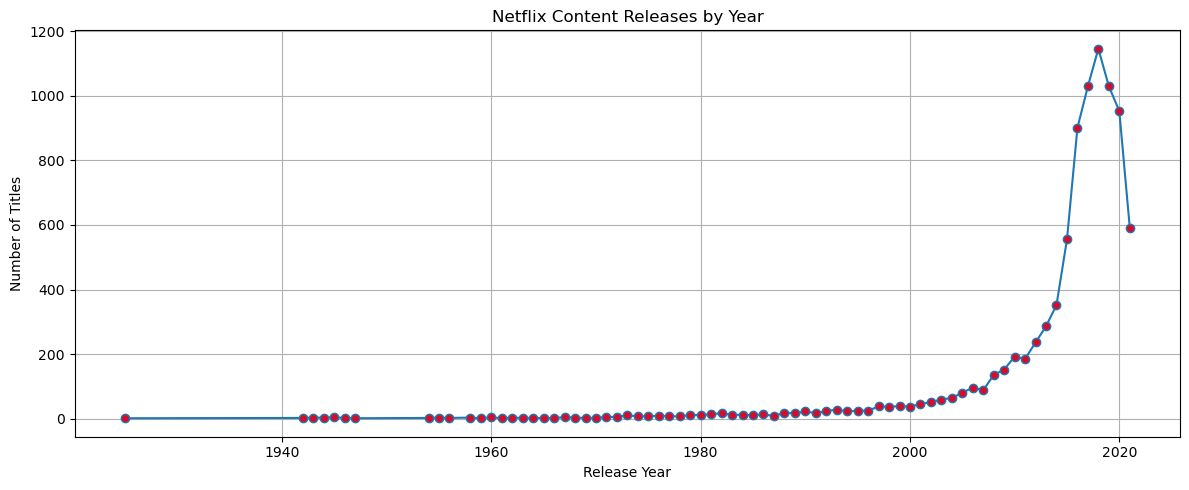

In [13]:
#Step 4 — Visualize Content Release Trends

#Step 4.1 — Create the trend chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(yearly_content['release_year'],yearly_content['content_count'],
         marker='o',markerfacecolor="#d60d28")
plt.title('Netflix Content Releases by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.tight_layout()
plt.show()

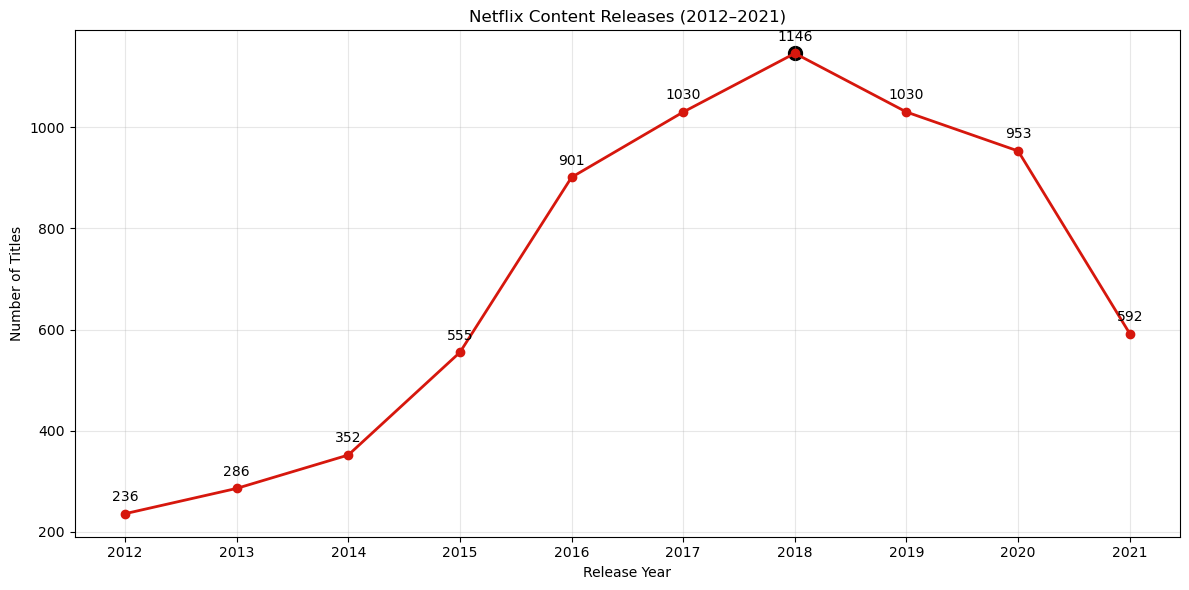

In [16]:
import matplotlib.pyplot as plt

# Select data from 2012 to 2021
recent_years = yearly_content[(yearly_content['release_year'] >= 2012) &
    (yearly_content['release_year'] <= 2021)]

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the trend
plt.plot(recent_years['release_year'],recent_years['content_count'],marker='o',
    linewidth=2,color="#d6170d")

# Add data labels
for x, y in zip(recent_years['release_year'],recent_years['content_count']):
    plt.text(x,y + 25,str(y),ha='center')

# Highlight the peak year
peak_year = recent_years.loc[recent_years['content_count'].idxmax()]
plt.scatter(peak_year['release_year'],peak_year['content_count'],
    s=100,color="#000000")

# Chart formatting
plt.title('Netflix Content Releases (2012–2021)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(recent_years['release_year'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
#Step 5 — Interpret Business Patterns

## Step 5: Business Insights

The analysis of Netflix content releases by year reveals several important trends:

- Netflix content represented in the dataset increased significantly from 2012 to 2018.
- The number of titles reached its highest point in **2018**, with **1,146 titles**.
- The largest year-over-year increase occurred in **2016**, when content increased by **346 titles** compared with 2015.
- After 2018, the number of titles declined, reaching **592 titles in 2021**.
- The largest year-over-year decline occurred in **2021**, with 361 fewer titles than in 2020.
- Overall, the dataset shows substantial growth in content releases during the 2012–2018 period, followed by a decline through 2021.

> **Note:** The decline in recent years should be interpreted carefully because the dataset may not contain complete representation of content released in those years. Therefore, these findings describe trends within the dataset rather than Netflix's complete production activity.